## Advanced Gamma Correction Algorithms

import required libraries

In [61]:
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

setup settings for plots

In [62]:
plt.rcParams['figure.figsize'] = [15, 5]
sns.set_style('whitegrid')

support functions

In [63]:
def read_image(path):
    """
    OpenCV читає у BGR.
    Перетворюємо у RGB та float32.
    """

    image = cv2.imread(path)

    if image is None:
        raise ValueError("Image not found.")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.astype(np.float32)

    return image


def show_images(images, titles):
    plt.figure(figsize=(18,6))

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i+1)

        plt.imshow(np.clip(img / 255.0, 0, 1))
        plt.title(title)
        plt.axis("off")

    plt.show()

default image

In [64]:
path = '../images/yield.png'
img = read_image(path)

### 1. Shades of Gray

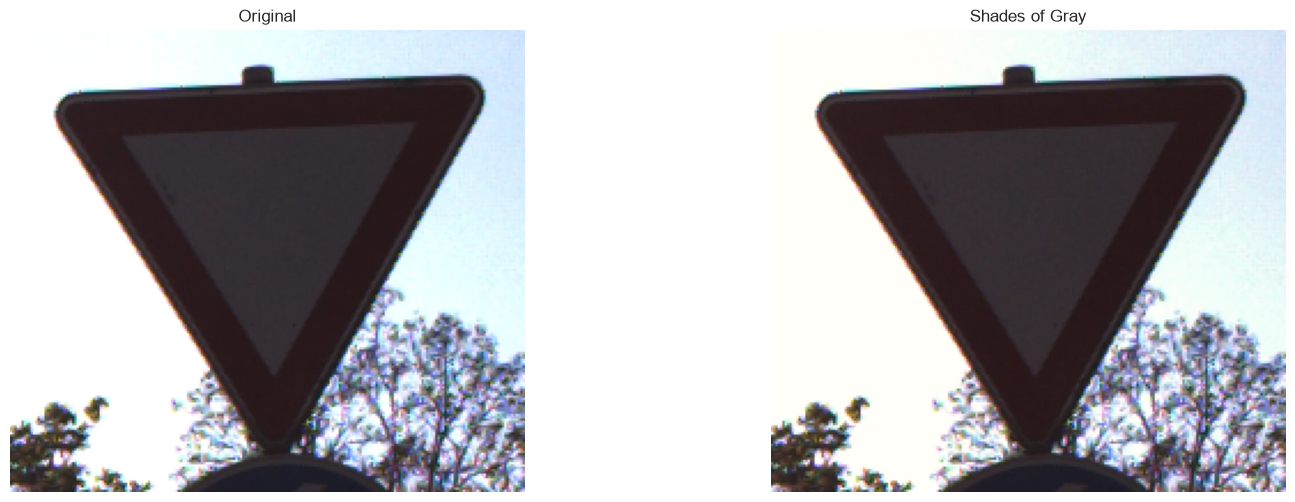

In [65]:
import numpy as np

def shades_of_gray(image, p=6):

    img = image.astype(np.float32).copy()

    illumination = np.power(
        np.mean(np.power(img, p), axis=(0,1)),
        1.0/p
    )

    gray = illumination.mean()

    scale = gray / illumination

    img *= scale

    return np.clip(img,0,255)

shades_gray_img = shades_of_gray(img)
show_images([img, shades_gray_img], ["Original", "Shades of Gray"])

### 2. Gray Edge

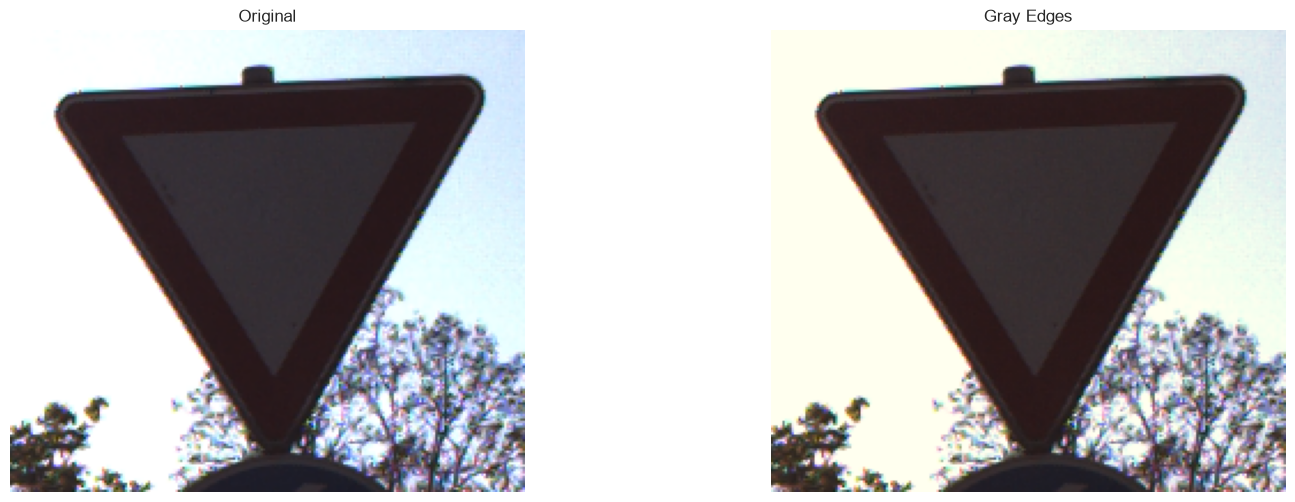

In [66]:
def gray_edge(image, p=6):

    img = image.astype(np.float32)

    gradients = []

    for c in range(3):

        gx = cv2.Sobel(img[:,:,c], cv2.CV_32F,1,0,ksize=3)

        gy = cv2.Sobel(img[:,:,c], cv2.CV_32F,0,1,ksize=3)

        g = np.sqrt(gx**2 + gy**2)

        gradients.append(g)

    gradients = np.stack(gradients, axis=2)

    illum = np.power(
        np.mean(np.power(gradients,p),axis=(0,1)),
        1/p
    )

    gray = illum.mean()

    scale = gray / illum

    result = img * scale

    return np.clip(result,0,255)

gray_edge_img = gray_edge(img)
show_images([img, gray_edge_img], ["Original", "Gray Edges"])

### 3. Single Scale Retinex (SSR)

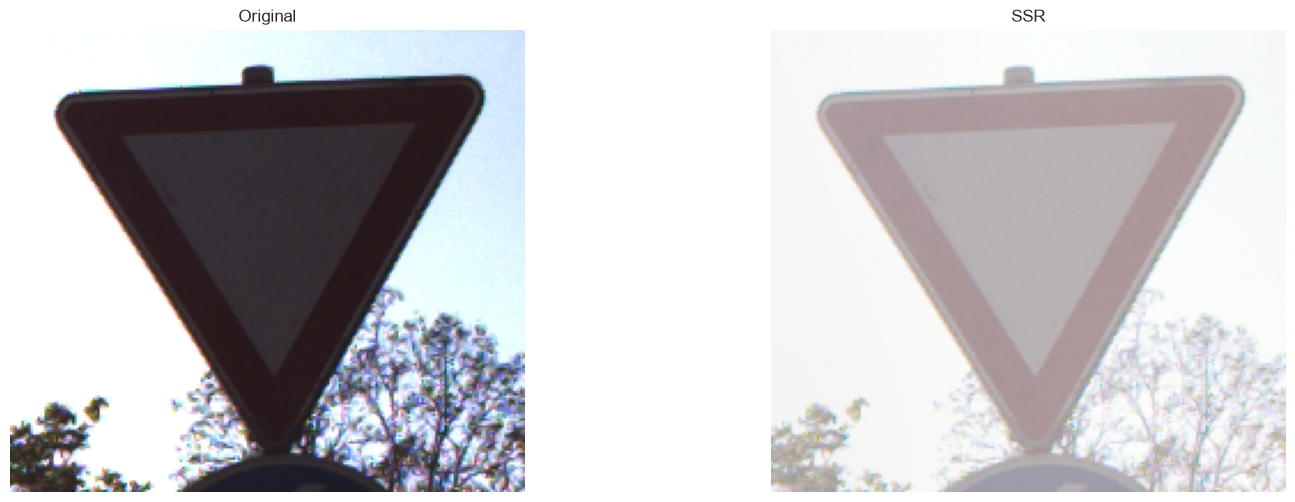

In [67]:
def SSR(image, sigma=80):

    img = image.astype(np.float32)+1

    blur = cv2.GaussianBlur(img,(0,0),sigma)

    retinex = np.log(img)-np.log(blur)

    retinex = cv2.normalize(
        retinex,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return retinex.astype(np.uint8)


ssr_img = SSR(img, sigma=80)

show_images([img, ssr_img], ["Original", "SSR"])

### 4. Multi Scale Retinex (MSR)

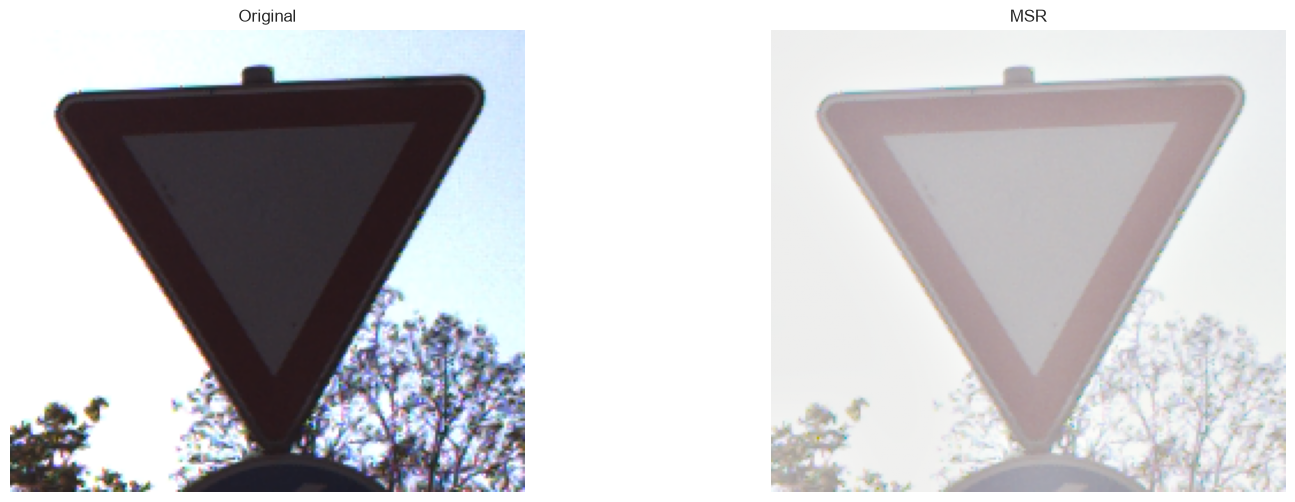

In [68]:
def MSR(image, sigmas=(15,80,250)):

    img = image.astype(np.float32)+1

    result = np.zeros_like(img)

    for sigma in sigmas:

        blur = cv2.GaussianBlur(img,(0,0),sigma)

        result += np.log(img)-np.log(blur)

    result /= len(sigmas)

    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return result.astype(np.uint8)

msr_img = MSR(img, sigmas=(15,80,250))

show_images([img, msr_img], ["Original", "MSR"])

### 5. Multi Scale Retinex with Color Restoration (MSRCR)

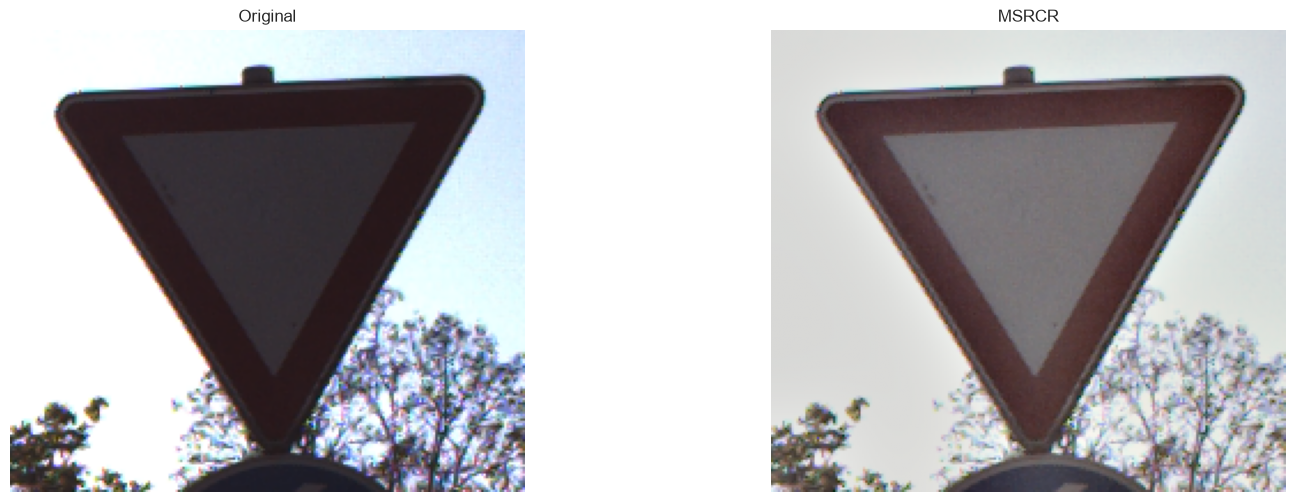

In [69]:
def MSRCR(
    image,
    sigmas=(15,80,250),
    alpha=125,
    beta=46,
    gain=1,
    offset=0
):

    img = image.astype(np.float32)+1

    msr = np.zeros_like(img)

    for sigma in sigmas:

        blur = cv2.GaussianBlur(img,(0,0),sigma)

        msr += np.log(img)-np.log(blur)

    msr /= len(sigmas)

    intensity = np.sum(img,axis=2,keepdims=True)

    color = beta*(np.log(alpha*img)-np.log(intensity))

    result = gain*(color*msr)+offset

    result = cv2.normalize(
        result,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    return result.astype(np.uint8)

msrcr_img = MSRCR(img, sigmas=(15,80,250), alpha=125, beta=46, gain=1, offset=0)

show_images([img, msrcr_img], ["Original", "MSRCR"])